# Main Figures (Figs. 1–4)

This notebook reads the pre-computed posteriors and CSV tables produced by `cip_model_bayesian_inference.ipynb` and assembles the four main figures of the manuscript.

| Figure | Content | Output file |
|--------|---------|-------------|
| **Fig. 1** | Simultaneous model fit vs. independent logistic; r(c) and K(c) | `figures/fig1.pdf` |
| **Fig. 2** | MIC robustness to sparse concentration sampling; CV comparison | `figures/fig2.pdf` |
| **Fig. 3** | Model fits across four medium perturbations; parameter subpanels | `figures/fig3.pdf` |
| **Fig. 4** | q vs r₀ and MIC vs r₀ across all conditions | `figures/fig4.pdf` |

**Prerequisites:** run `cip_model_bayesian_inference.ipynb` first to generate all `results/*.nc` and `results/*.csv` files.

> **Unit Conversion Warning:** The pre-computed posterior data loaded here represents concentrations in **µg/mL**. In this notebook, we multiply the labels/axes by 1000 to display the final plots in **ng/mL**, matching the figures in the manuscript.

In [1]:
from functions import *

---
## Figure 1 — Simultaneous model fit outperforms independent logistic fits

This is the core demonstration figure of the paper.  It shows, for one representative biological replicate (replicate 2), that:

- **(A)** The simultaneous mechanistic fit (Eq. 5) accurately describes all 11 CIP dose-response curves with a single shared parameter set, including the sharp transition near the MIC.
- **(B)** Independent logistic fits to each concentration separately work well at low CIP but break down near the MIC, where the nearly flat growth curves are unidentifiable.
- **(C–D)** The derived r(c) and K(c) curves from the mechanistic model are smooth and consistent across concentrations, while the independent fits scatter wildly near the MIC.

The same four-panel layout is repeated for biological replicates 1, 3, 4, 5 in Supplementary Figs. S2–S5.

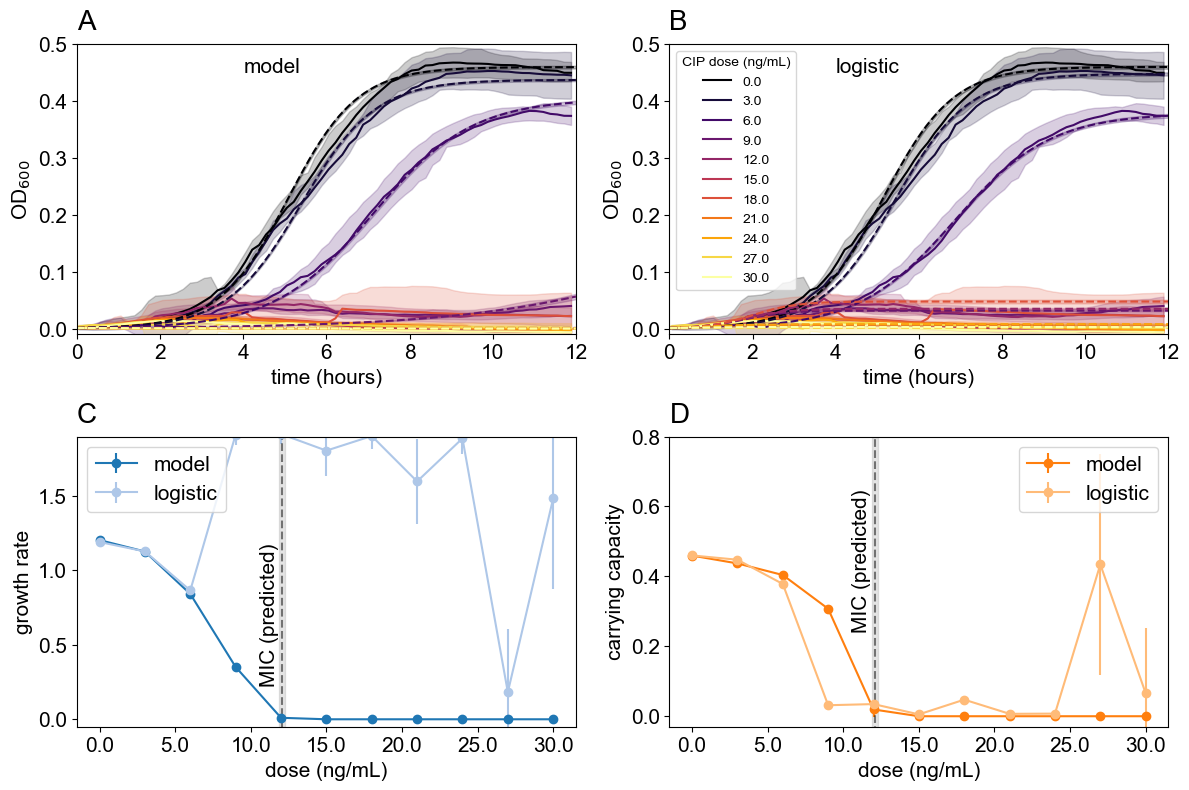

In [2]:
medium = 'standard'  # M9 + 0.2% glucose
y0     = 0.001       # inoculum OD_600

DF = pd.read_csv('data/cip_dose_response_all.csv')
DF_CIP = DF[(DF.medium == medium) & (DF.Hours < 12)]

# Color map: one color per CIP concentration, shared across all panels
unique_doses = sorted(DF_CIP['dosisAb'].unique())
colors       = plt.get_cmap('inferno', len(unique_doses))
color_dict   = {dose: colors(i) for i, dose in enumerate(unique_doses)}

fig = plt.figure(figsize=(12, 8))

# ------------------------------------------------------------------
# Panel A: raw data (median + IQR) overlaid with the mechanistic model
# ------------------------------------------------------------------
rep      = 2    # representative replicate shown in the main figure
filename = f"results/cip_model_standard_{rep}_12h.nc"

ax = fig.add_subplot(2, 2, 1)
by_label = plot_data(DF_CIP[DF_CIP.rep == rep], ax)  # solid lines = data median
plot_pred(ax, filename, unique_doses, y0)              # dashed lines = model posterior predictive
ax.set_xlim([0, 12])
ax.set_ylim([-0.01, 0.5])
ax.text(4, 0.45, 'model', fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.0, 1.05, 'A', fontsize=20, transform=ax.transAxes)
ax.set_xlabel(ax.get_xlabel(), fontsize=15)
ax.set_ylabel(ax.get_ylabel(), fontsize=15)

# ------------------------------------------------------------------
# Panel B: same data overlaid with the per-curve independent logistic fits
# ------------------------------------------------------------------
ax = fig.add_subplot(2, 2, 2)
by_label = plot_data(DF_CIP[DF_CIP.rep == rep], ax)
plot_pred_logistic(rep, ax, unique_doses, y0)  # independent logistic posteriors
ax.legend(by_label.values(), by_label.keys(),
          title="CIP dose (ng/mL)", ncols=1, loc='upper left')
ax.set_xlim([0, 12])
ax.set_ylim([-0.01, 0.5])
ax.text(4, 0.45, 'logistic', fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.0, 1.05, 'B', fontsize=20, transform=ax.transAxes)
ax.set_xlabel(ax.get_xlabel(), fontsize=15)
ax.set_ylabel(ax.get_ylabel(), fontsize=15)

# Compute the posterior MIC for this replicate (used to draw the MIC marker in C and D)
idata        = az.from_netcdf(filename)
MICavg, MICstd = get_mic(idata)

# Load the pre-computed r/K summary table (posterior mean +/- SD per concentration)
rK = pd.read_csv(f'results/rK_{rep}_12h.csv')

# Two-color map for the model vs. logistic comparison
colors = plt.get_cmap('tab20')

# ------------------------------------------------------------------
# Panel C: growth rate r(c) — model (blue) vs. independent logistic (light blue)
# ------------------------------------------------------------------
ax = fig.add_subplot(2, 2, 3)
ax.errorbar(rK.c, rK.Ravg,  yerr=rK.Rstd,  marker='o', color=colors(0), label='model')
ax.errorbar(rK.c, rK.RavgL, yerr=rK.RstdL, marker='o', color=colors(1), label='logistic')
ax.set_xlabel('dose (ng/mL)', fontsize=15)
ax.set_ylabel('growth rate', fontsize=15)
ax.set_ylim([-0.05, 1.9])
# Mark the predicted MIC as a vertical dashed line + shaded uncertainty band
ax.vlines(MICavg, ymin=-0.05, ymax=1.9, ls='dashed', color='k', alpha=0.5)
ax.fill_between([MICavg - MICstd, MICavg + MICstd], -0.05, 1.9, alpha=0.1, color='k')
ax.text(MICavg - 0.0015, 0.25, 'MIC (predicted)', rotation=90, fontsize=15)
ax.legend(fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.0, 1.05, 'C', fontsize=20, transform=ax.transAxes)
# Convert x-axis from ug/mL to ng/mL for readability
Ticks  = np.arange(0, 0.031, 0.005)
ax.set_xticks(Ticks)
ax.set_xticklabels([1000 * z for z in Ticks])

# ------------------------------------------------------------------
# Panel D: carrying capacity K(c) — model (orange) vs. independent logistic (light orange)
# ------------------------------------------------------------------
ax = fig.add_subplot(2, 2, 4)
ax.errorbar(rK.c, rK.Kavg,  yerr=rK.Kstd,  marker='o', color=colors(2), label='model')
ax.errorbar(rK.c, rK.KavgL, yerr=rK.KstdL, marker='o', color=colors(3), label='logistic')
ax.set_xlabel('dose (ng/mL)', fontsize=15)
ax.set_ylabel('carrying capacity', fontsize=15)
ax.set_ylim([-0.03, 0.8])
ax.vlines(MICavg, ymin=-0.05, ymax=0.8, ls='dashed', color='k', alpha=0.5)
ax.fill_between([MICavg - MICstd, MICavg + MICstd], -0.03, 0.8, alpha=0.1, color='k')
ax.text(MICavg - 0.0015, 0.25, 'MIC (predicted)', rotation=90, fontsize=15)
ax.legend(fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.0, 1.05, 'D', fontsize=20, transform=ax.transAxes)
Ticks  = np.arange(0, 0.031, 0.005)
ax.set_xticks(Ticks)
ax.set_xticklabels([1000 * z for z in Ticks])

fig.tight_layout()
fig.savefig('figures/fig1.pdf', bbox_inches='tight')

---
## Figure 2 — MIC estimation is robust to sparse concentration sampling

This figure demonstrates two complementary aspects of MIC robustness:

- **(A) Robustness to the number of concentrations:** using only 4–5 CIP concentrations (instead of 11) gives MIC estimates that agree with the full-dataset reference to within 8% or 0.1%, respectively.  The box plots show the full posterior MIC distribution for each subset size $n$; the red dashed line marks the reference MIC from all 11 concentrations.
- **(B) Robustness within the posterior:** even though $q$ can have a large coefficient of variation (CV), the MIC CV remains low — comparable to that of $r_0$ and $c_0$.  This follows from the sensitivity analysis (Eq. 9 in the manuscript): MIC sensitivity to $q$ is suppressed by the factor $1 + \alpha\,x/(1+x)$.

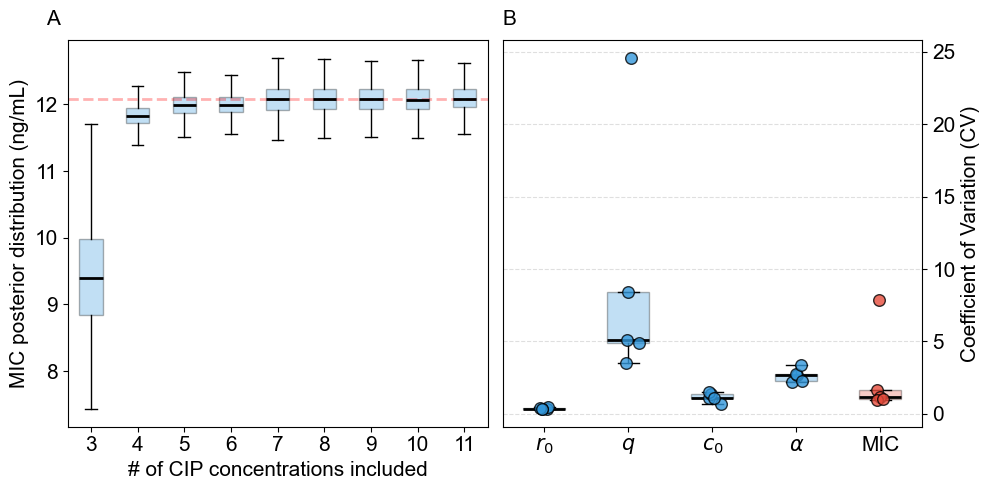

In [22]:
fig = plt.figure(figsize=(10, 5))

# ------------------------------------------------------------------
# Panel A: MIC posterior distribution as a function of n concentrations used
# ------------------------------------------------------------------
ax = fig.add_subplot(1, 2, 1)

df = pd.read_csv('results/mic_convergence_data_linear_add.csv')

# Build a list of arrays — one per n — for matplotlib's boxplot
unique_concs = sorted(df['num_conc'].unique())
data_to_plot = [df[df['num_conc'] == conc]['mic_value'].values for conc in unique_concs]

bplot = ax.boxplot(
    data_to_plot,
    tick_labels=unique_concs,
    patch_artist=True,
    showfliers=False,        # hide outliers for clarity
    widths=0.5,
    medianprops={'color': 'black', 'linewidth': 2},
    boxprops={'alpha': 0.3}
)
for patch in bplot['boxes']:
    patch.set_facecolor('#3498db')

# Reference MIC from the complete 11-concentration fit (replicate 2)
ax.axhline(0.0120822361271672, color='red', linestyle='--', linewidth=2, alpha=0.3)

ax.set_xlabel('# of CIP concentrations included', fontsize=15)
ax.set_ylabel('MIC posterior distribution (ng/mL)', fontsize=15)
Ticks  = np.arange(0.008, 0.013, 0.001)
ax.set_yticks(Ticks)
ax.set_yticklabels([8,9,10,11,12])

ax.tick_params(labelsize=15)
ax.text(-0.05, 1.04, 'A', fontsize=15, transform=ax.transAxes)

# ------------------------------------------------------------------
# Panel B: CV comparison — individual parameters vs. MIC
# ------------------------------------------------------------------
ax = fig.add_subplot(1, 2, 2)

DFL = pd.read_csv('results/cip_model_cv.csv')

# Order: input parameters first, then the derived MIC output
plot_order  = ['r0', 'q', 'c0', 'alpha', 'MIC']
plot_labels = ['$r_0$', '$q$', '$c_0$', '$\\alpha$', 'MIC']
plot_data_arrays = [DFL[col].values for col in plot_order]

bp = ax.boxplot(
    plot_data_arrays,
    tick_labels=plot_labels,
    patch_artist=True,
    showfliers=False,
    widths=0.5,
    medianprops={'color': 'black', 'linewidth': 2},
    boxprops={'alpha': 0.3}
)

# Blue for input parameters, red for the MIC output
box_colors = ['#3498db', '#3498db', '#3498db', '#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

# Overlay individual replicate points with slight jitter for legibility
for i, col in enumerate(plot_order):
    y = DFL[col].values
    x = np.random.normal(i + 1, 0.04, size=len(y))  # small horizontal jitter
    ax.scatter(x, y, color=box_colors[i], edgecolor='black', alpha=0.8, s=70, zorder=3)

ax.set_ylabel('Coefficient of Variation (CV)', fontsize=15)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.text(0, 1.04, 'B', fontsize=15, transform=ax.transAxes)

plt.tight_layout()
plt.savefig('figures/fig2.pdf', bbox_inches='tight')

---
## Figure 3 — Model fits across four medium perturbations

This composite figure tests the generality of the model across twelve experimental conditions.  For each medium (glucose, glycerol, TMP, CHL), each of the three co-treatment or carbon-source doses occupies one column of an upper row of growth-curve panels.  A lower row of parameter subpanels shows how $r_0$, $K_0$, $q$, $c_0$, $\alpha$, and MIC change with the medium dose.

Key biological findings:
- **Glucose / glycerol:** reducing the carbon source primarily lowers $K_0$ while leaving $r_0$ and the MIC largely unchanged.
- **TMP / CHL:** bacteriostatic co-treatment reduces both $r_0$ and $q$ together, causing a large MIC increase (4.4-fold for TMP, 9.6-fold for CHL).

The layout is assembled using nested `GridSpec` objects to pack growth curves and parameter plots into a single figure.

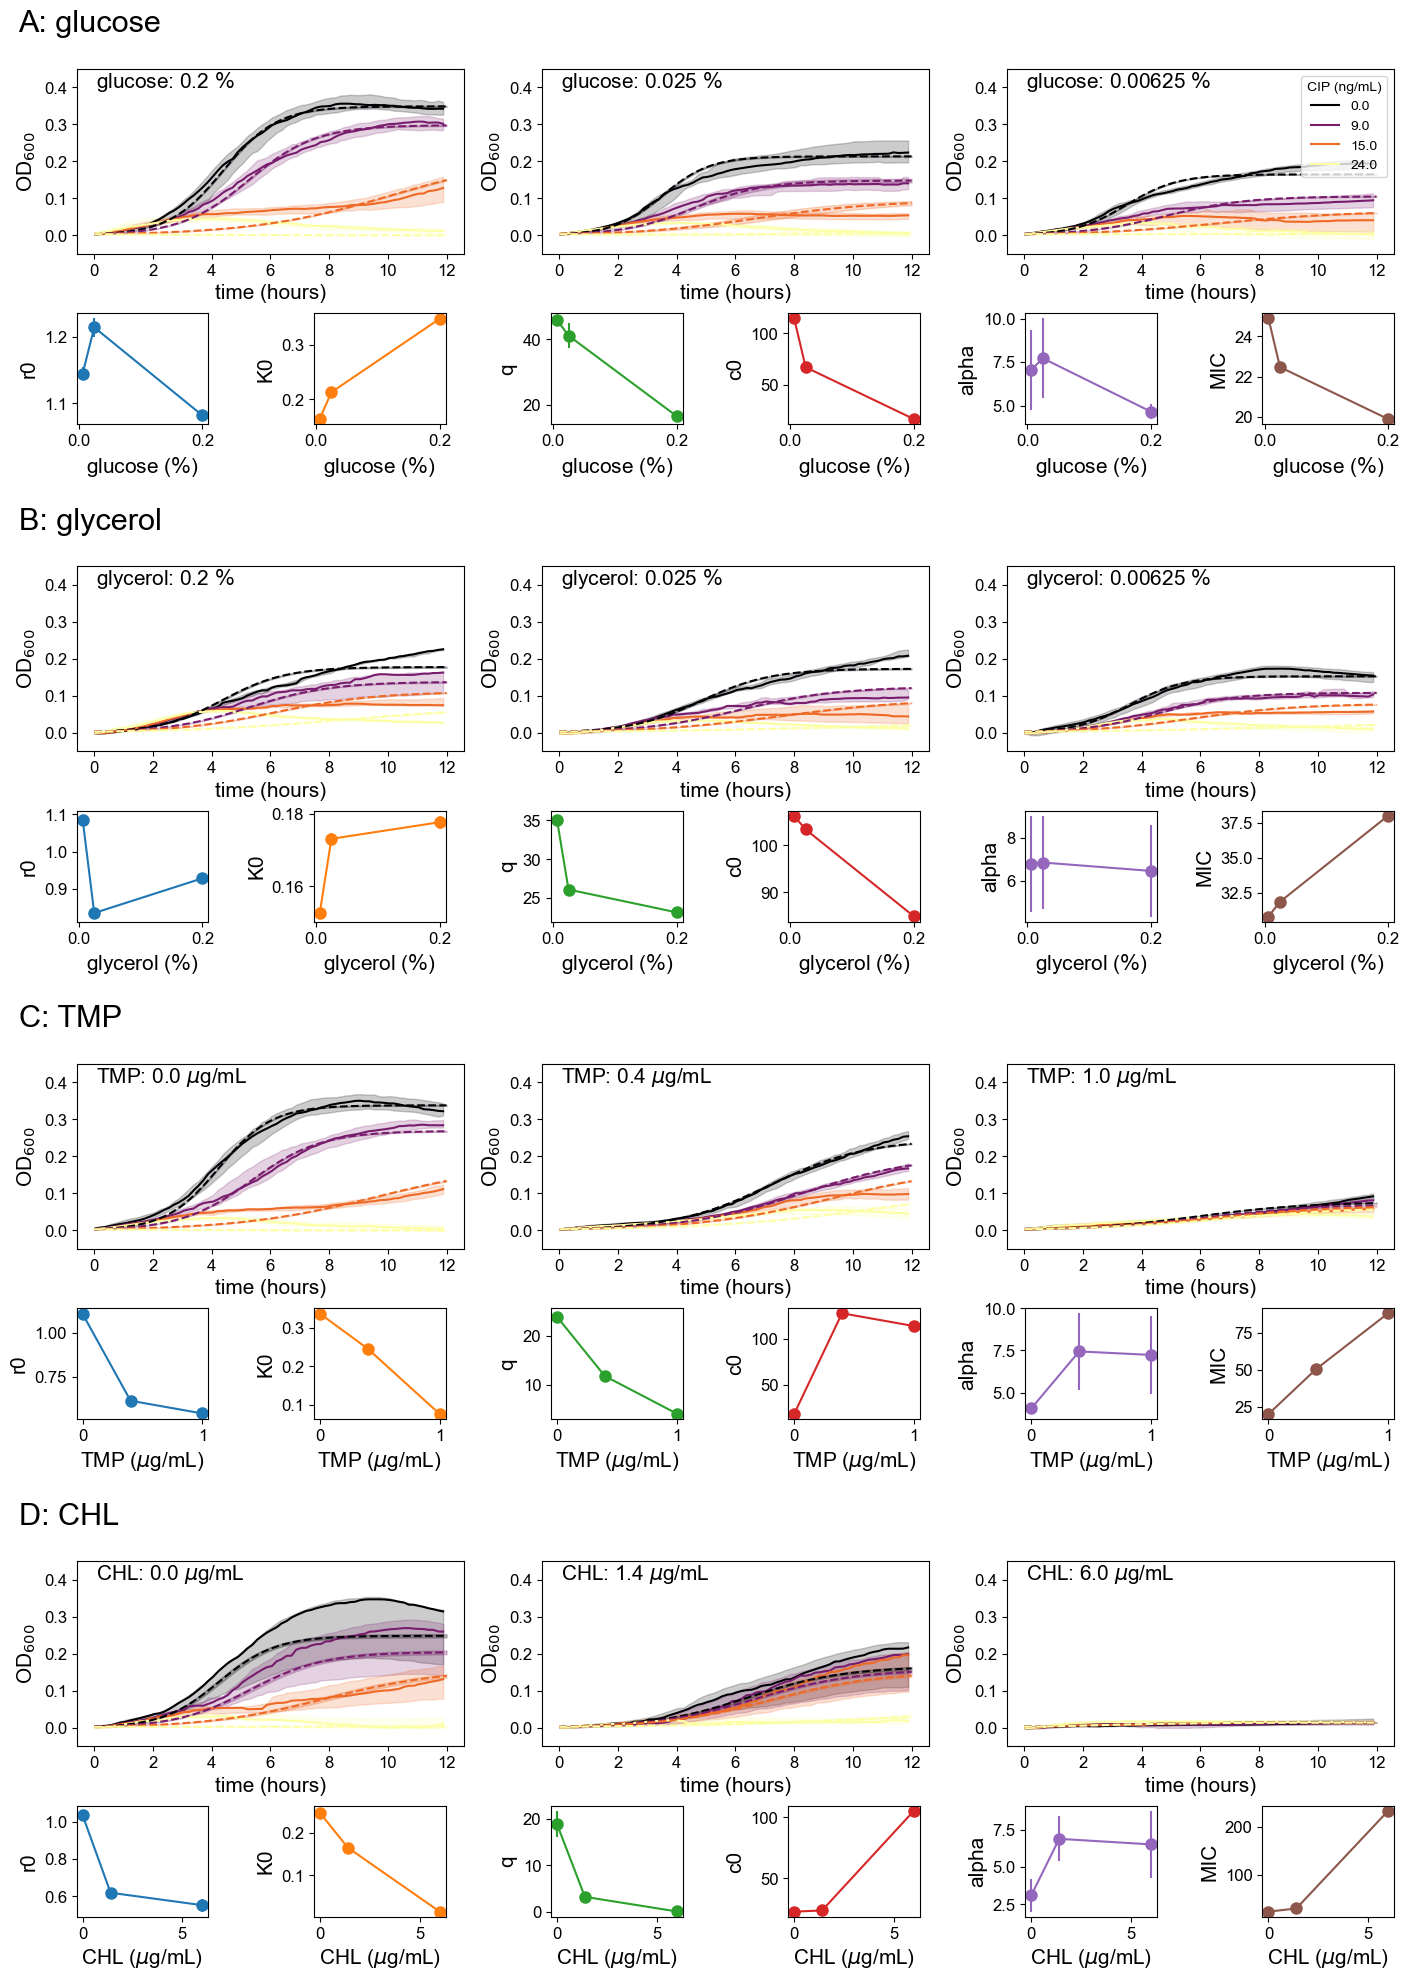

In [23]:
Medium = ['glucose', 'glycerol', 'TMP', 'CHL']
Pars   = ["r0", "K0", "q", "c0", "alpha", "MIC"]
y0     = 0.003

fig = plt.figure(figsize=(17, 24))

# Outer grid: one row per medium type (4 rows total)
outer_gs = gridspec.GridSpec(4, 1, hspace=0.4)

# Load the pre-assembled parameter table (one row per condition)
ParDF = pd.read_csv('results/parameters_table.csv')

for idx, medium in enumerate(Medium):
    # Each outer row contains: top half = growth curves (1x3), bottom half = parameters (1x6)
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[idx],
        height_ratios=[1, 0.6], hspace=0.4
    )
    gs_pred = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=inner_gs[0], wspace=0.2)
    gs_pars = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=inner_gs[1], wspace=0.8)

    # Load and filter data for this medium
    DF    = pd.read_csv('data/cip_dose_response_all.csv')
    DF    = DF[(DF.Hours < 12) & (DF.medium == medium)]
    COND  = sorted(DF.dosis.unique(), reverse=True)

    # TMP and CHL are displayed in increasing dose order (0 -> max) for visual clarity
    if medium in ('TMP', 'CHL'):
        COND = sorted(DF.dosis.unique(), reverse=False)

    unique_doses = sorted(DF['dosisAb'].unique())
    colors       = plt.get_cmap('inferno', len(unique_doses))
    color_dict   = {dose: colors(i) for i, dose in enumerate(unique_doses)}

    # ---------------------------------------------------------------
    # Upper row: one growth-curve panel per co-treatment/carbon dose
    # ---------------------------------------------------------------
    for i, cond in enumerate(COND):
        ax = fig.add_subplot(gs_pred[i])

        # Section label (A = glucose, B = glycerol, C = TMP, D = CHL)
        if i == 0:
            ax.text(-0.15, 1.2, f'{chr(65 + idx)}: {medium}',
                    fontsize=22, transform=ax.transAxes)

        DFcond       = DF[DF.dosis == cond]
        unique_doses = DFcond.dosisAb.unique()
        by_label     = plot_data(DFcond, ax)

        filename = f"results/cip_model_{medium}_{cond}_12h.nc"
        plot_pred(ax, filename, unique_doses, y0)

        ax.set_ylim([-0.05, 0.45])

        # Annotate with the medium dose (units differ between conditions)
        if medium in ('TMP', 'CHL'):
            ax.text(0.05, 0.4, f'{medium}: {cond} $\\mu$g/mL', fontsize=15)
        else:
            ax.text(0.05, 0.4, f'{medium}: {cond} $\\%$', fontsize=15)

        ax.tick_params(labelsize=12)
        ax.set_xlabel(ax.get_xlabel(), fontsize=15)
        ax.set_ylabel(ax.get_ylabel(), fontsize=15)

        # Add a CIP legend only once (top-right panel of the glucose block)
        if i == 2 and idx == 0:
            ax.legend(by_label.values(), by_label.keys(), title="CIP (ng/mL)", loc='upper right')

    # ---------------------------------------------------------------
    # Lower row: one subplot per model parameter showing how it varies with dose
    # ---------------------------------------------------------------
    colors      = plt.get_cmap('tab20')
    ParDFcond   = ParDF[ParDF.medium == medium]

    for i, par in enumerate(Pars):
        ax = fig.add_subplot(gs_pars[i])

        Paravg = par + '_mean'
        Parstd = par + '_std'

        if par=='c0' or par=='MIC':#express in ng/mL for clarity
            ax.errorbar(
                ParDFcond.concentration,
                1000*ParDFcond[Paravg],
                yerr=1000*ParDFcond[Parstd],
                marker='o', color=colors(2 * i), markersize=8
            )
        else:
            ax.errorbar(
                ParDFcond.concentration,
                ParDFcond[Paravg],
                yerr=ParDFcond[Parstd],
                marker='o', color=colors(2 * i), markersize=8
            )

        # X-axis label with appropriate units
        if medium in ('TMP', 'CHL'):
            ax.set_xlabel(medium + ' ($\\mu$g/mL)', fontsize=15)
        else:
            ax.set_xlabel(medium + ' ($\\%$)', fontsize=15)

        ax.set_ylabel(par, fontsize=15)
        ax.tick_params(labelsize=12)

plt.savefig('figures/fig3.pdf', bbox_inches='tight')

---
## Figure 4 — Inferred parameters reproduce growth–death coupling and MIC dichotomy

This figure connects the model parameters to two well-established results from the antibiotic biology literature (Bren et al. 2023; Kratz & Banerjee 2024):

- **(A) $q$ vs $r_0$:** under bacteriostatic co-treatment (TMP, CHL), the killing efficiency $q$ decreases proportionally to $r_0$ (Pearson $r = 0.93$), reproducing the growth–death coupling.  Fewer active replication forks in slower-growing cells means fewer lethal CIP–gyrase collisions.  Carbon-source conditions do not follow the same trend because nutrient limitation does not activate the stress response.
- **(B) MIC vs $r_0$:** bacteriostatic drugs raise the MIC dramatically (4.4-fold for TMP, 9.6-fold for CHL), while carbon-source variation leaves it essentially unchanged (< 1.5-fold).  This dichotomy mirrors the experimental observation of Bren et al., here reproduced from sub-MIC logistic fits.

The linear trends for TMP and CHL in panel A are obtained by a small Bayesian linear regression fitted inline.

In [5]:
# One color per experimental condition
conditions = ["glucose", "glycerol", "TMP", "CHL"]
colors     = {'glucose': 'blue', 'TMP': 'red', 'glycerol': 'green', 'CHL': 'purple'}

df = pd.read_csv("results/parameters_table.csv")

# -----------------------------------------------------------------------
# Bayesian linear regression for TMP: q ~ a + b * r0
# Used to draw the posterior-predictive band in panel A.
# -----------------------------------------------------------------------
def line(x, a, b):
    return a + b * x

dfTMP = df[df.medium == 'TMP']
with pm.Model() as generative_model:
    x = pm.Data("r0", dfTMP.r0_mean)
    y = pm.Data("q",  dfTMP.q_mean)
    a     = pm.Normal('a', sigma=40)
    b     = pm.Normal('b', sigma=40)
    sigma = pm.HalfNormal('sigma')
    likelihood = pm.Normal("y_obs", mu=line(x, a, b), sigma=sigma, observed=y)
    idataTMP = pm.sample(draws=1000, tune=2000, target_accept=0.95,
                         cores=4, return_inferencedata=True)

# Bayesian linear regression for CHL: same model
dfCHL = df[df.medium == 'CHL']
with pm.Model() as generative_model:
    x = pm.Data("r0", dfCHL.r0_mean)
    y = pm.Data("q",  dfCHL.q_mean)
    a     = pm.Normal('a', sigma=40)
    b     = pm.Normal('b', sigma=40)
    sigma = pm.HalfNormal('sigma')
    likelihood = pm.Normal("y_obs", mu=a + b * x, sigma=sigma, observed=y)
    idataCHL = pm.sample(draws=1000, tune=2000, target_accept=0.95,
                         cores=4, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]
/home/pcatalan/micromamba/envs/pymc/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 3 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


In [6]:
# Optional: quick summary of the TMP linear regression coefficients
az.summary(idataTMP)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-4.682,3.762,-11.498,2.614,0.120,0.094,1024.0,1180.0,1.0
b,23.942,4.772,14.725,32.337,0.155,0.126,981.0,1097.0,1.0
sigma,2.220,0.559,1.270,3.291,0.016,0.011,1172.0,1664.0,1.0


In [7]:
# Optional: quick summary of the CHL linear regression coefficients
az.summary(idataCHL)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-20.888,1.859,-24.170,-16.977,0.078,0.116,647.0,478.0,1.00
b,38.433,2.404,33.659,43.038,0.100,0.149,663.0,493.0,1.01
sigma,0.757,0.464,0.136,1.644,0.018,0.012,547.0,579.0,1.00


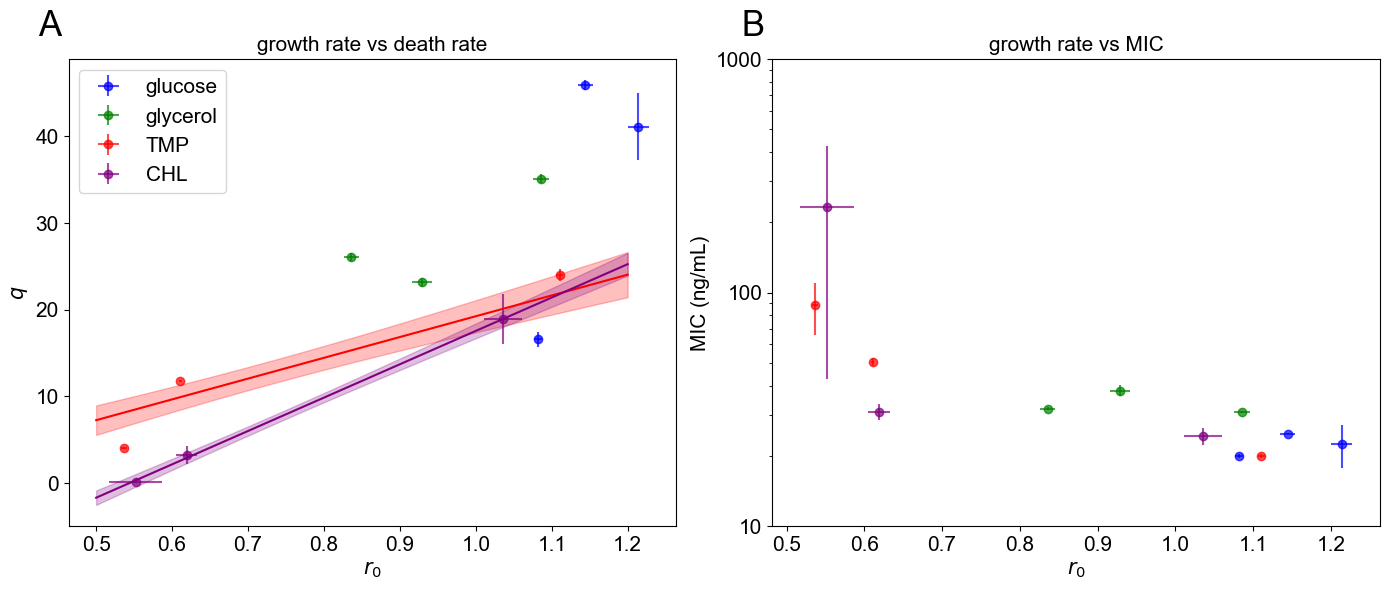

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot error bars for each experimental condition
for cond in conditions:
    df_cond = pd.read_csv("results/parameters_table.csv")
    df_cond = df_cond[df_cond.medium == cond]

    # Panel A: killing efficiency q vs. antibiotic-free growth rate r0
    ax1.errorbar(
        df_cond['r0_mean'], df_cond['q_mean'],
        xerr=df_cond['r0_std'], yerr=df_cond['q_std'],
        fmt='o', label=cond, color=colors[cond], alpha=0.7
    )

    # Panel B: MIC vs. r0 (log scale on y to spread out the large dynamic range)
    ax2.errorbar(
        df_cond['r0_mean'], df_cond['MIC_mean'],
        xerr=df_cond['r0_std'], yerr=df_cond['MIC_std'],
        fmt='o', label=cond, color=colors[cond], alpha=0.7
    )

# ------------------------------------------------------------------
# Overlay posterior-predictive band for the TMP linear trend (Panel A)
# ------------------------------------------------------------------
posterior = idataTMP.posterior.stack(samples=("draw", "chain"))
all_sims  = []
xp = np.linspace(0.5, 1.2, 100)
for i in np.random.randint(0, posterior.samples.size, 1000):
    ai     = posterior["a"].values[i]
    bi     = posterior["b"].values[i]
    all_sims.append(ai + bi * xp)
average_sim = np.mean(all_sims, axis=0)
std_sim     = np.std(all_sims, axis=0)
ax1.plot(xp, average_sim, ls='-', color=colors['TMP'])
ax1.fill_between(xp, average_sim - std_sim, average_sim + std_sim,
                 color=colors['TMP'], alpha=0.25)

# Overlay posterior-predictive band for the CHL linear trend (Panel A)
posterior = idataCHL.posterior.stack(samples=("draw", "chain"))
all_sims  = []
for i in np.random.randint(0, posterior.samples.size, 1000):
    ai = posterior["a"].values[i]
    bi = posterior["b"].values[i]
    all_sims.append(ai + bi * xp)
average_sim = np.mean(all_sims, axis=0)
std_sim     = np.std(all_sims, axis=0)
ax1.plot(xp, average_sim, ls='-', color=colors['CHL'])
ax1.fill_between(xp, average_sim - std_sim, average_sim + std_sim,
                 color=colors['CHL'], alpha=0.25)

# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------
ax1.set_xlabel(r'$r_0$', fontsize=15)
ax1.set_ylabel(r'$q$', fontsize=15)
ax1.set_title(r'growth rate vs death rate', fontsize=15)
ax1.legend(fontsize=15)
ax1.text(-0.05, 1.05, 'A', transform=ax1.transAxes, fontsize=25)
ax1.tick_params(labelsize=15)

ax2.set_xlabel(r'$r_0$', fontsize=15)
ax2.set_ylabel('MIC (ng/mL)', fontsize=15)
ax2.set_title(r'growth rate vs MIC', fontsize=15)
ax2.text(-0.05, 1.05, 'B', transform=ax2.transAxes, fontsize=25)
ax2.set_yscale('log')   # log scale to show both the low (carbon) and high (bacteriostatic) MIC values
Ticks  = [0.01, 0.1, 1]
ax2.set_yticks(Ticks)
ax2.set_yticklabels([10, 100, 1000])
ax2.tick_params(labelsize=15)

plt.tight_layout()
plt.savefig('figures/fig4.pdf', bbox_inches='tight')